# otwin 07 · All of it, on eight years of real field data

**Question.** Everything so far ran on laboratory cells. A lender, a plant operator or an
auditor works with a different kind of evidence: years of logs from systems in the field, and a
handful of manual capacity tests as ground truth. Does the protocol hold up there?

**What otwin does here.** The whole chain from notebooks 03–06 — anchored forecast, cross-fleet
conformal band, measured coverage, manifest, refusal — on the only public dataset that has
multi-year field logs *and* periodic capacity tests: 21 home-storage systems in Germany, three
chemistries, 2015–2022 (Figgener et al., *Nature Energy* 2024, CC BY 4.0).

**What you write yourself.** The fade model — deliberately the simplest one that can hold an
anchor: a linear fleet rate per chemistry. Notebook 08 asks whether anything richer earns its
place. And the loader for the paper's Source Data spreadsheet.

**What you will learn**

1. what "calibrating on other systems" means, and why a system with three tests has no other option
2. how coverage is *measured* when the test systems were never in the calibration set
3. why the band is wide, and what narrows it (hint: not the model)
4. what the twin refuses on this fleet, and why a lender should read that first

*Real data. Runtime ≈ 1 min once the Source Data file is present. Opens in Colab.*

> **Getting the data.** The notebook tries to download the Fig. 2 Source Data spreadsheet from
> Nature. If that fails, download it from the article's *Source data* links and upload it when
> asked. Without any file it runs on a synthetic fleet matched to the paper's statistics, and
> stamps every figure DEMO — the pipeline is checked, the claim is not.


## Setup

Install, style, and the data file. The route used is printed, together with `MODE`.

In [1]:
# otwin from PyPI. No clone, no path surgery, no vendored copy of the model code.
!pip install -q otwin openpyxl 2>/dev/null
import otwin, sys
print("otwin", otwin.__version__, "| python", sys.version.split()[0])
from packaging.version import Version
assert Version(otwin.__version__) >= Version("0.3.0"), "needs otwin >= 0.3.0 for otwin.forecast.conformal"


otwin 0.3.1 | python 3.13.15


In [2]:
# Inlined plotting style. Self-contained on purpose.
import os, json, warnings
from datetime import datetime, timezone
import numpy as np, pandas as pd
from otwin.forecast.conformal import (split_conformal, horizon_conformal,
                                      conformal_quantile, ConformalBand)
from otwin.forecast import picp, mpiw, interval_score
from otwin import TwinManifest
from otwin.interfaces.manifest import Provenance
from otwin.advise import Envelope
import matplotlib; import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

TEAL, RED, SLATE, GRID, OBS = "#0E7C86", "#C1121F", "#4A5568", "#E5E9EC", "black"
AMBER = "#B7791F"; BAND_ALPHA = 0.18
CHEM_COLOR = {"SLMO": SLATE, "MNMC": AMBER, "MLFP": TEAL}
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","savefig.facecolor":"white",
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "xtick.labelsize":10,"ytick.labelsize":10,"legend.fontsize":10,
    "axes.grid":True,"grid.color":GRID,"grid.linewidth":0.8,"axes.axisbelow":True,
    "figure.dpi":110,"savefig.dpi":200,
})
FIGDIR="fig"; os.makedirs(FIGDIR, exist_ok=True)
def despine(ax):
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#333333"); ax.spines["bottom"].set_color("#333333")
def save(fig, name):
    p=os.path.join(FIGDIR, name if name.endswith(".png") else name+".png")
    fig.savefig(p, dpi=200, bbox_inches="tight"); plt.show(); print("saved", p); return p
def put(ax, text):  # stamps DEMO on every figure when no real file was found
    if MODE == "DEMO":
        ax.text(0.5, 0.5, "DEMO DATA\nnot the RWTH measurements", transform=ax.transAxes,
                ha="center", va="center", fontsize=22, color=RED, alpha=0.25, rotation=20)
    ax.set_title(text)


In [3]:
import urllib.request

ART = "art%3A10.1038%2Fs41560-024-01620-9"
ESM = "https://static-content.springer.com/esm/" + ART + "/MediaObjects/41560_2024_1620_{}_ESM.xlsx"
SOURCE = {  # figure -> (candidate filenames, URL)
    "fig2_capacity_tests": (["SourceData_Fig2.xlsx", "41560_2024_1620_MOESM4_ESM.xlsx", "data/SourceData_Fig2.xlsx"], ESM.format("MOESM4")),
    "fig4_estimates":      (["SourceData_Fig4.xlsx", "41560_2024_1620_MOESM6_ESM.xlsx", "data/SourceData_Fig4.xlsx"], ESM.format("MOESM6")),
    "fig5_rates":          (["SourceData_Fig5.xlsx", "41560_2024_1620_MOESM7_ESM.xlsx", "data/SourceData_Fig5.xlsx"], ESM.format("MOESM7")),
}

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

FILES, ROUTE = {}, {}
for key, (cands, url) in SOURCE.items():
    for p in cands:
        if os.path.exists(p):
            FILES[key], ROUTE[key] = p, "(c) local file"; break
    if key not in FILES:
        try:
            dst = cands[0]
            urllib.request.urlretrieve(url, dst)
            if os.path.getsize(dst) > 2000:
                FILES[key], ROUTE[key] = dst, "(a) downloaded"
            else:
                os.remove(dst)
        except Exception as e:
            ROUTE[key] = f"download failed: {type(e).__name__}"
if "fig2_capacity_tests" not in FILES and _in_colab():
    print("Upload SourceData_Fig2.xlsx (required) and, if you have them, Fig4 / Fig5:")
    from google.colab import files
    for name in files.upload():
        for key, (cands, _) in SOURCE.items():
            if any(tok in name for tok in ("Fig2", "MOESM4")) and key == "fig2_capacity_tests": FILES[key], ROUTE[key] = name, "(b) uploaded"
            if any(tok in name for tok in ("Fig4", "MOESM6")) and key == "fig4_estimates":      FILES[key], ROUTE[key] = name, "(b) uploaded"
            if any(tok in name for tok in ("Fig5", "MOESM7")) and key == "fig5_rates":          FILES[key], ROUTE[key] = name, "(b) uploaded"

MODE = "REAL" if "fig2_capacity_tests" in FILES else "DEMO"
for key in SOURCE: print(f"{key:<22} {ROUTE.get(key, 'not found'):<28} {FILES.get(key, '')}")
print("\nMODE:", MODE)
if MODE == "DEMO":
    print("No RWTH source file found. The notebook will run on a SYNTHETIC fleet matched to the\n"
          "published fleet statistics so the pipeline can be checked. NOTHING below is evidence\n"
          "about the real systems until MODE == 'REAL'.")


fig2_capacity_tests    (c) local file               SourceData_Fig2.xlsx
fig4_estimates         (c) local file               SourceData_Fig4.xlsx
fig5_rates             (c) local file               SourceData_Fig5.xlsx

MODE: REAL


## 1 · One row per field capacity test

The Source Data sheet has one row per manual test: system, chemistry, capacity in Ah, age in
years, equivalent full cycles. There is no nominal capacity in the sheet, so **state of health
is relative to each system's first test** — which is exactly what a technical adviser has on
day one: a commissioning test, not a datasheet.

*Look at:* 60 tests, 18 systems (three of the 21 have no successful test), three chemistry
classes, and LFP is one of them.

In [4]:
def inspect_workbook(path, max_rows=6):
    xl = pd.ExcelFile(path)
    print(f"{path}: {len(xl.sheet_names)} sheet(s)")
    for sh in xl.sheet_names:
        df = xl.parse(sh, header=None, nrows=max_rows)
        print(f"  [{sh}] shape(head)={df.shape}")
        print(df.to_string(max_cols=12, max_colwidth=18).replace("\n", "\n    "))
    return xl

def _find_header_row(df, must_have=()):
    # the header is the first row where at least two cells look like column names
    for i in range(min(15, len(df))):
        row = [str(v).strip().lower() for v in df.iloc[i].tolist()]
        if sum(any(k in v for k in ("soh","age","efc","year","system","id","type","chem","date","month","capacity")) for v in row) >= 2:
            return i
    return 0

def _guess(cols, *keys, exclude=(), df=None):
    for c in cols:
        if df is not None and pd.api.types.is_datetime64_any_dtype(df[c]): continue
        cl = str(c).lower()
        if any(k in cl for k in keys) and not any(e in cl for e in exclude):
            return c
    return None

def load_capacity_tests(path, colmap=None):
    # Fig. 2 Source Data, sheet 'a)-c)': one row per manual field capacity test with columns
    # Time, ID, Chemistry (LMO/NMC/LFP), Capacity_Ah, Energy_kWh, Age_a, EFC_count.
    # Sheet 'd)' is the discharge-current shape of Fig. 2d and is not a capacity test.
    # No nominal capacity is published in this sheet, so SoH here is RELATIVE TO THE SYSTEM'S
    # FIRST FIELD TEST. That is exactly the quantity the anchored forecast below uses, and it
    # is what a technical adviser has on day one: a commissioning test, not a datasheet.
    xl = pd.ExcelFile(path)
    sheet = next((sh for sh in xl.sheet_names if "a)" in sh.lower()), xl.sheet_names[0])
    df = xl.parse(sheet)
    df.columns = [str(c).strip() for c in df.columns]
    cm = {"system": "ID", "chem": "Chemistry", "cap": "Capacity_Ah", "age_yr": "Age_a", "efc": "EFC_count", "time": "Time"}
    cm.update(colmap or {})
    missing = [v for v in cm.values() if v not in df.columns]
    assert not missing, f"columns not found: {missing}; available: {list(df.columns)}"
    t = pd.DataFrame({"system": df[cm["system"]].astype(str),
                      "chem": df[cm["chem"]].astype(str).str.upper(),
                      "cap_Ah": pd.to_numeric(df[cm["cap"]], errors="coerce"),
                      "age_yr": pd.to_numeric(df[cm["age_yr"]], errors="coerce"),
                      "efc": pd.to_numeric(df[cm["efc"]], errors="coerce"),
                      "time": pd.to_datetime(df[cm["time"]], errors="coerce")})
    t = t.dropna(subset=["cap_Ah", "age_yr"]).sort_values(["system", "age_yr"]).reset_index(drop=True)
    t["chem"] = t["chem"].map(lambda s: "SLMO" if "LMO" in s else "MNMC" if "NMC" in s else "MLFP" if "LFP" in s else s)
    t["soh"] = t.cap_Ah / t.groupby("system").cap_Ah.transform("first")   # relative to first test
    t["sheet"] = sheet
    return t

COLMAP = {}   # override only if the Source Data column names change, e.g. {"cap": "Capacity in Ah"}

def demo_fleet(seed=0):
    # Synthetic fleet matched to the PUBLISHED fleet statistics (Figgener et al. 2024, Fig. 5):
    # mean fade 3.1 / 1.9 / 2.0 pp per year for SLMO / MNMC / MLFP, ~2 pp/yr spread within type,
    # ~200-250 EFC/yr, about three capacity tests per system over up to eight years.
    rng = np.random.default_rng(seed); rows = []
    plan = [("SLMO", 7, 0.031, 250), ("MNMC", 6, 0.019, 200), ("MLFP", 8, 0.020, 200)]
    k = 0
    for chem, n, rate, efc_yr in plan:
        for _ in range(n):
            k += 1; r = max(0.006, rng.normal(rate, 0.006)); z = rng.uniform(0.9, 1.25)
            t0 = rng.uniform(0.3, 1.5); span = rng.uniform(3.0, 6.5); ntest = rng.integers(2, 5)
            ages = np.sort(np.r_[t0, rng.uniform(t0, min(8.0, t0+span), ntest-1)])
            caps = [13.5*(1.0 - r*a**z + rng.normal(0, 0.012)) for a in ages]
            for a, c in zip(ages, caps):
                rows.append(dict(system=f"ID_{k:02d}", chem=chem, age_yr=float(a), cap_Ah=float(c),
                                 efc=float(efc_yr*a*rng.uniform(0.8,1.2)), sheet="demo"))
    d = pd.DataFrame(rows).sort_values(["system","age_yr"]).reset_index(drop=True)
    d["soh"] = d.cap_Ah / d.groupby("system").cap_Ah.transform("first")
    return d

if MODE == "REAL":
    tests = load_capacity_tests(FILES["fig2_capacity_tests"], COLMAP)
else:
    tests = demo_fleet()

# sanity checks: these are what a wrong COLMAP fails on
assert tests["soh"].between(0.4, 1.3).all(), "SoH (relative to first test) outside [0.4, 1.3]: wrong column?"
assert tests["age_yr"].between(0, 12).all(), "age outside [0, 12] years: wrong column or unit?"
assert tests["system"].nunique() >= 5, "fewer than 5 systems recognised"
print(tests.groupby("chem").agg(systems=("system","nunique"), tests=("soh","size"),
                                 age_min=("age_yr","min"), age_max=("age_yr","max"),
                                 soh_min=("soh","min")).round(3))
print(f"\n{len(tests)} capacity tests on {tests.system.nunique()} systems  [{MODE}]")
if MODE == "REAL":
    print("expected: 60 tests on 21 systems (paper). SoH is relative to each system's FIRST field test.")


      systems  tests  age_min  age_max  soh_min
chem                                           
MLFP        6     19    1.278    7.306    0.814
MNMC        6     19    0.084    7.743    0.847
SLMO        6     22    2.069    8.098    0.752

60 capacity tests on 18 systems  [REAL]
expected: 60 tests on 21 systems (paper). SoH is relative to each system's FIRST field test.


## 2 · The forecast is anchored, and the residuals come from other systems

A lender's question is anchored: "the last test read X; what will it read in year N?" So the
forecast starts at each system's **first** test and extrapolates with the **fleet rate for its
chemistry, estimated on every other system**.

The calibration residuals cannot come from the system's own history — three tests give no
history. They come from the other systems: leave one out, anchor each of the rest on its first
test, record the error of the fleet forecast at each later test. Those residuals go into
`split_conformal` and `horizon_conformal`, exactly as in notebook 04 — the only change is that
the "origins" are now systems instead of cycles.

*Look at:* how many held-out tests are scored, and how small each calibration set is (about a
dozen residuals per chemistry). That number decides everything below.

In [5]:
LEVEL = 0.90
HBIN  = 1.0   # horizon bin width in years (a conformal quantile needs >= 9 residuals per bin at 90 %)

def per_system_rate(g):
    # slope of the system's own tests; None if it has fewer than two
    if len(g) < 2: return None
    a, s = g.age_yr.to_numpy(float), g.soh.to_numpy(float)
    return float(-np.polyfit(a, s, 1)[0])

def fleet_rate(df, chem, exclude=None):
    rs = []
    for sid, g in df[df.chem == chem].groupby("system"):
        if sid == exclude: continue
        r = per_system_rate(g)
        if r is not None: rs.append(r)
    if len(rs) == 0:   # fall back to the whole fleet if a class has no other system
        return fleet_rate(df, None, exclude) if chem is not None else np.nan, 0
    return float(np.mean(rs)), len(rs)

def anchored_residuals(df, chem, exclude):
    # calibration residuals: for every OTHER system of this chemistry, anchor at its first test
    # and score the fleet-rate forecast (fleet rate computed without the held-out system) at
    # each later test.  Returns (residuals, horizons_in_years).
    rate, n = fleet_rate(df, chem, exclude)
    res, hz = [], []
    for sid, g in df[df.chem == chem].groupby("system"):
        if sid == exclude or len(g) < 2: continue
        a, s = g.age_yr.to_numpy(float), g.soh.to_numpy(float)
        pred = s[0] - rate*(a[1:] - a[0])
        res.extend((s[1:] - pred).tolist()); hz.extend((a[1:] - a[0]).tolist())
    return np.asarray(res), np.asarray(hz), rate, n

# Leave-one-system-out over the whole fleet
rows = []
for sid, g in tests.groupby("system"):
    if len(g) < 2: continue                     # nothing to score
    chem = g.chem.iloc[0]
    res, hz, rate, nsys = anchored_residuals(tests, chem, exclude=sid)
    if res.size < 9:                            # too few for a 90 % quantile in this class alone
        res, hz, rate, nsys = anchored_residuals(tests.assign(chem="ALL"), "ALL", exclude=sid)
        pooled = True
    else:
        pooled = False
    a, s = g.age_yr.to_numpy(float), g.soh.to_numpy(float)
    h = a[1:] - a[0]; pred = s[0] - rate*h
    # (i) pooled split-conformal half-width, all horizons together
    band_pool = split_conformal(res, level=LEVEL)
    # (ii) horizon-aware half-width, residuals binned by whole years of horizon
    hb = np.maximum(1, np.ceil(hz / HBIN)).astype(int); H = int(np.ceil(h.max() / HBIN))
    try:
        band_h = horizon_conformal(res, hb, level=LEVEL, max_horizon=max(H, 1))
        hw_h = band_h.half_width[np.maximum(1, np.ceil(h / HBIN)).astype(int) - 1]
        extrap = band_h.extrapolated[np.maximum(1, np.ceil(h / HBIN)).astype(int) - 1]
    except Exception as e:
        hw_h = np.full_like(h, np.inf); extrap = np.ones_like(h, dtype=bool)
    for j in range(len(h)):
        rows.append(dict(system=sid, chem=chem, horizon=float(h[j]), soh_obs=float(s[1+j]),
                         soh_pred=float(pred[j]), rate=rate, n_fleet=nsys, pooled_class=pooled,
                         hw_pooled=float(band_pool.half_width[0]), n_cal=int(band_pool.n_calibration),
                         hw_horizon=float(hw_h[j]), extrapolated=bool(extrap[j])))
R = pd.DataFrame(rows)
print(f"{len(R)} held-out capacity tests scored on {R.system.nunique()} systems "
      f"(each with >= 2 tests); calibration sets of {R.n_cal.min()}–{R.n_cal.max()} residuals")
print(R.groupby("chem").size().rename("held-out tests"))


42 held-out capacity tests scored on 17 systems (each with >= 2 tests); calibration sets of 10–37 residuals
chem
MLFP    13
MNMC    13
SLMO    16
Name: held-out tests, dtype: int64


## 3 · Measured coverage

Three bands on the same forecasts: **A** naive (the fleet's in-sample fit residuals — what a
warranty appendix contains), **B** pooled cross-system, **C** horizon-aware. The `lower_edge_hit`
column is the one a firm-capacity commitment would be made against.

*Look at:* band A is well short of 90 %; band B, built on systems the held-out one never
influenced, delivers about 90 %; band C covers where it can and **refuses** most horizons — a
90 % quantile needs nine residuals per yearly bin and this fleet rarely has them.

In [6]:
def score(R, hw_col, label):
    ok = np.isfinite(R[hw_col])
    lo = R.soh_pred - R[hw_col]; hi = R.soh_pred + R[hw_col]
    y = R.soh_obs.to_numpy(float)
    out = dict(band=label, n=int(ok.sum()),
               picp=float(picp(y[ok], lo[ok].to_numpy(), hi[ok].to_numpy())),
               mpiw=float(mpiw(lo[ok].to_numpy(), hi[ok].to_numpy())),
               interval_score=float(interval_score(y[ok], lo[ok].to_numpy(), hi[ok].to_numpy(), level=LEVEL)),
               refused=int((~ok).sum()))
    # the one-sided lower edge is what a commitment is made against
    out["lower_edge_hit"] = float(np.mean(y[ok] >= lo[ok].to_numpy()))
    return out

# a naive band for contrast: the fleet's in-sample residual spread, no held-out step at all
ins = []
for chem, g in tests.groupby("chem"):
    rate, _ = fleet_rate(tests, chem)
    for sid, gg in g.groupby("system"):
        if len(gg) < 2: continue
        a, s = gg.age_yr.to_numpy(float), gg.soh.to_numpy(float)
        fit = np.polyval(np.polyfit(a, s, 1), a); ins.extend((s - fit).tolist())
R["hw_naive"] = float(conformal_quantile(np.abs(np.asarray(ins)), LEVEL))

scores = pd.DataFrame([score(R, "hw_naive",   "A  naive: in-sample fit residuals"),
                       score(R, "hw_pooled",  "B  pooled cross-system, split conformal"),
                       score(R, "hw_horizon", "C  horizon-aware cross-system")])
print(f"target coverage {LEVEL:.0%}   [{MODE}]\n")
print(scores.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
by_chem = R.assign(hit=lambda d: (d.soh_obs >= d.soh_pred - d.hw_pooled) & (d.soh_obs <= d.soh_pred + d.hw_pooled)) \
           .groupby("chem").agg(n=("hit","size"), picp_pooled=("hit","mean"), mean_hw=("hw_pooled","mean"))
print("\nband B by chemistry class:\n", by_chem.round(3).to_string())


target coverage 90%   [REAL]

                                   band  n  picp  mpiw  interval_score  refused  lower_edge_hit
      A  naive: in-sample fit residuals 42 0.571 0.067           0.389        0           0.905
B  pooled cross-system, split conformal 42 0.905 0.193           0.272        0           0.952
          C  horizon-aware cross-system  5 1.000 0.272           0.272       37           1.000

band B by chemistry class:
        n  picp_pooled  mean_hw
chem                          
MLFP  13        0.846    0.124
MNMC  13        1.000    0.081
SLMO  16        0.875    0.086


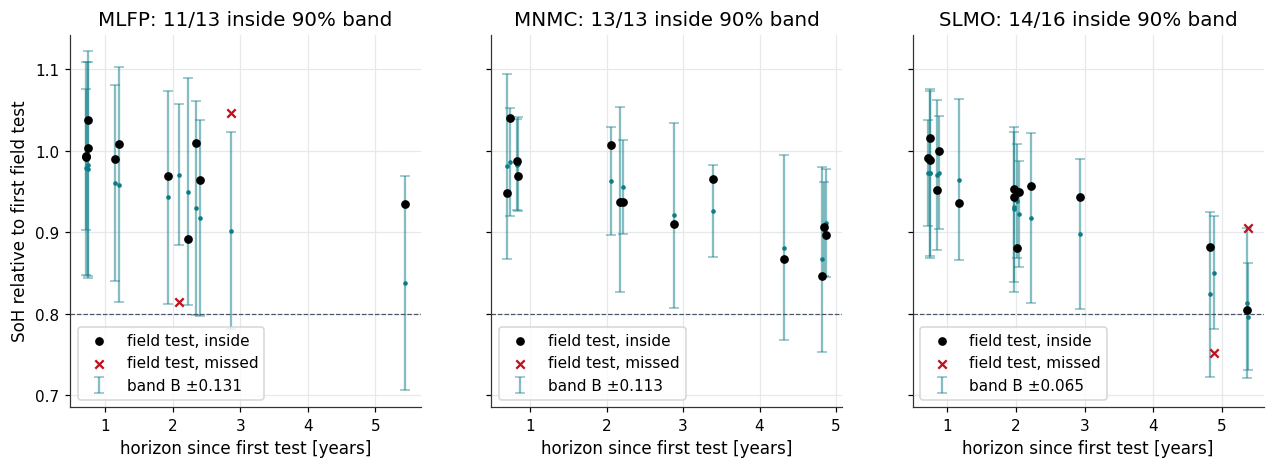

saved fig/07_fig1_heldout_tests.png


'fig/07_fig1_heldout_tests.png'

In [7]:
# Figure 1: every held-out capacity test against its anchored forecast and band, by horizon
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
for ax, (chem, g) in zip(axes, R.groupby("chem")):
    g = g.sort_values("horizon")
    ax.errorbar(g.horizon, g.soh_pred, yerr=g.hw_pooled, fmt="none", ecolor=TEAL, alpha=0.5, capsize=3, label=f"band B ±{g.hw_pooled.iloc[0]:.3f}")
    inside = (g.soh_obs - g.soh_pred).abs() <= g.hw_pooled
    ax.scatter(g.horizon[inside], g.soh_obs[inside], color=OBS, s=22, zorder=3, label="field test, inside")
    ax.scatter(g.horizon[~inside], g.soh_obs[~inside], color=RED, s=30, zorder=4, marker="x", label="field test, missed")
    ax.plot(g.horizon, g.soh_pred, ".", color=TEAL, ms=4)
    ax.axhline(0.80, color=SLATE, lw=0.8, ls="--"); ax.set_xlabel("horizon since first test [years]")
    put(ax, f"{chem}: {inside.sum()}/{len(g)} inside {LEVEL:.0%} band")
    despine(ax); ax.legend(loc="lower left")
axes[0].set_ylabel("SoH relative to first field test")
save(fig, "07_fig1_heldout_tests")


## 4 · Why the band is wide, and what narrows it

Band B is roughly 19 SoH points wide. That is not the model's fault. Look at the residual set
behind band C: only the first year has enough points for a quantile to exist; every later year
is shaded.

*Look at:* the shaded years. Two years of monthly estimates from **one** asset is a larger
calibration set than this entire published fleet. The width is the price of public data, and
the argument for asking an operator for their logs.

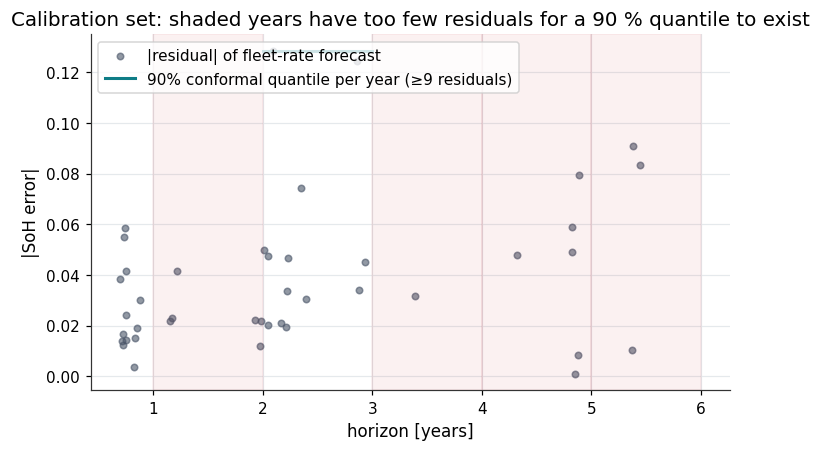

saved fig/07_fig2_residual_growth.png


'fig/07_fig2_residual_growth.png'

In [8]:
# Figure 2: residual growth with horizon, the calibration set behind band C
res_all, hz_all = [], []
for chem in R.chem.unique():
    r, h, *_ = anchored_residuals(tests, chem, exclude=None); res_all.append(r); hz_all.append(h)
res_all = np.concatenate(res_all); hz_all = np.concatenate(hz_all)
bins = np.arange(0, np.ceil(hz_all.max()) + 1)
q = []
for lo_, hi_ in zip(bins[:-1], bins[1:]):
    m = (hz_all > lo_) & (hz_all <= hi_)
    q.append(conformal_quantile(np.abs(res_all[m]), LEVEL) if m.sum() >= 9 else np.nan)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.scatter(hz_all, np.abs(res_all), s=18, color=SLATE, alpha=0.6, label="|residual| of fleet-rate forecast")
ax.step(bins[1:], q, where="pre", color=TEAL, lw=2, label=f"{LEVEL:.0%} conformal quantile per year (≥9 residuals)")
for b, qq, in zip(bins[1:], q):
    if np.isnan(qq): ax.axvspan(b-1, b, color=RED, alpha=0.06)
ax.set_xlabel("horizon [years]"); ax.set_ylabel("|SoH error|"); despine(ax); ax.legend(loc="upper left")
put(ax, "Calibration set: shaded years have too few residuals for a 90 % quantile to exist")
save(fig, "07_fig2_residual_growth")


## 5 · The manifest, and the refusal

Everything above goes into a `TwinManifest`: validated by leave-one-system-out, calibrated with
the measured coverage of band B. `Envelope` then takes three questions.

*Look at:* a year-2 LFP system asking three years ahead is answered. A twelve-year horizon is
refused — the field tests stop at six years and nothing can be *measured* beyond them. A
chemistry the fleet never contained is refused. Those refusals are the part of the figure to
show first: a due-diligence report that cannot say no is a warranty curve with an interval
drawn on it.

In [9]:
age_lo, age_hi = float(tests.age_yr.min()), float(tests.age_yr.max())
h_max_years = int(np.ceil(R.horizon.max()))
cov_B = float(scores.loc[scores.band.str.startswith("B"), "picp"].iloc[0])

manifest = TwinManifest(
    name="fleet_fade_band_rwth_hss", model_class="empirical_law", model_kind="anchored_linear_fade",
    n_states=2, n_inputs=0,
    provenance=Provenance(created=datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
                          otwin_version=otwin.__version__,
                          data_source="Figgener et al. 2024, doi:10.5281/zenodo.12091223 (Source Data Fig. 2)",
                          notes=f"MODE={MODE}; {len(tests)} field capacity tests on {tests.system.nunique()} systems"),
    parameters={f"rate_{c}": fleet_rate(tests, c)[0] for c in tests.chem.unique()},
    estimated=tuple(f"rate_{c}" for c in tests.chem.unique()),
    validation=TwinManifest.validated_by("leave_one_system_out", leakage_free=True,
                                         n_systems=int(tests.system.nunique()), horizon_years=h_max_years),
    calibration=TwinManifest.calibrated_by("split_conformal_cross_system", empirical_coverage=cov_B,
                                           level=LEVEL, mean_half_width=float(R.hw_pooled.mean())),
    extra={"chemistries": sorted(tests.chem.unique().tolist()), "duty": "residential PV self-consumption, Germany",
           "scale": "5-15 kWh systems", "systems_with_tests": int(tests.system.nunique())},
)
print("is_validated:", manifest.is_validated, "| is_white_box:", manifest.is_white_box)

env = Envelope(state_bounds=[(age_lo, age_hi), (0.75, 1.05)], max_horizon=h_max_years,
               requires_validated=True, requires_calibrated=True)

def ask(label, age, soh, horizon, chem):
    v = env.check(state=[age, soh], horizon=horizon, manifest=manifest, wants_interval=True)
    chem_ok = chem in manifest.extra["chemistries"]
    verdict = "ANSWER" if (v and chem_ok) else "REFUSE"
    reasons = [str(b) for b in v.breaches] if not v else []
    if not chem_ok: reasons.append(f"chemistry: '{chem}' not in the calibration fleet {manifest.extra['chemistries']}")
    print(f"{label:<44} -> {verdict}")
    for r_ in reasons: print(f"{'':<47}{r_}")
    return verdict

v1 = ask("year-2 LFP system, +3 years, wants a band", 2.0, 0.95, 3, "MLFP")
v2 = ask("year-1 NMC system, +12 years, wants a band", 1.0, 0.98, 12, "MNMC")
v3 = ask("year-2 NCA system, +3 years, wants a band", 2.0, 0.95, 3, "NCA")


is_validated: True | is_white_box: False
year-2 LFP system, +3 years, wants a band    -> ANSWER
year-1 NMC system, +12 years, wants a band   -> REFUSE
                                               horizon: beyond the validated forecast horizon (asked for 12, validated to 6)
year-2 NCA system, +3 years, wants a band    -> REFUSE
                                               chemistry: 'NCA' not in the calibration fleet ['MLFP', 'MNMC', 'SLMO']


## 6 · Change one thing

- **Calibrate per chemistry vs pooled.** Notebook 08 shows that pooling residuals across
  chemistries takes the band from ~12 residuals to ~40 and narrows it by 15 % — before any model
  change. Try `anchored_residuals(tests.assign(chem="ALL"), "ALL", exclude=sid)` for every system.
- **A one-sided band.** The lender cares about the lower edge only. Rebuild band B at the 95 %
  one-sided level and compare `lower_edge_hit` and width.
- **Route B.** Set `RUN_ROUTE_B = True` (and the CSV column names) to build monthly capacity
  estimates from the 21 GB raw record — hours, not minutes, and a calibration set a hundred times
  larger. The cell is written and switched off.

In [10]:
RUN_ROUTE_B = False
ZENODO = "https://zenodo.org/records/12091223/files/{}?download=1"
RAW_COLS = dict(time="Time", current="I_bat", voltage="U_bat")   # <-- set after opening one CSV
SYSTEMS_TO_RUN = range(1, 22)

def f2e_capacity_estimates(csv_path, cols, v_eoc_pct=99.0, v_eod_pct=1.0, rest_A=0.5, rest_s=600):
    # One capacity estimate per full-to-empty pass: integrate current between an end-of-charge
    # rest (voltage in its top percentile, |I| < rest_A for rest_s) and the next end-of-discharge
    # rest.  Returns a DataFrame(date, Ah).  Crude by design: no OCV fit, no offset-current
    # correction.  Good enough to produce a monthly series; replace with the paper's method
    # from Metadata_and_Code.zip for the published accuracy.
    df = pd.read_csv(csv_path, usecols=[cols["time"], cols["current"], cols["voltage"]])
    t = pd.to_datetime(df[cols["time"]]); i = df[cols["current"]].to_numpy(float); v = df[cols["voltage"]].to_numpy(float)
    dt = np.diff(t.astype("int64").to_numpy()) / 1e9; dt = np.r_[dt, dt[-1] if dt.size else 1.0]
    v_hi, v_lo = np.nanpercentile(v, v_eoc_pct), np.nanpercentile(v, v_eod_pct)
    rest = np.abs(i) < rest_A
    # run-length encode rests
    idx = np.flatnonzero(np.diff(np.r_[0, rest.astype(int), 0]))
    starts, ends = idx[::2], idx[1::2]
    marks = []
    for a, b in zip(starts, ends):
        if (t.iloc[b-1] - t.iloc[a]).total_seconds() < rest_s: continue
        vm = np.nanmedian(v[a:b])
        if vm >= v_hi: marks.append(("F", b-1))
        elif vm <= v_lo: marks.append(("E", a))
    out = []
    for (k1, a), (k2, b) in zip(marks[:-1], marks[1:]):
        if k1 == "F" and k2 == "E" and b > a:
            Ah = -np.sum(i[a:b] * dt[a:b]) / 3600.0
            if Ah > 0: out.append(dict(date=t.iloc[a], Ah=float(Ah)))
    return pd.DataFrame(out)

if RUN_ROUTE_B:
    import zipfile, glob, shutil
    os.makedirs("raw", exist_ok=True); est_frames = []
    for k in SYSTEMS_TO_RUN:
        name = f"Data_ID_{k:02d}.zip"; zpath = os.path.join("raw", name)
        if not os.path.exists(zpath):
            print("downloading", name); urllib.request.urlretrieve(ZENODO.format(name), zpath)
        with zipfile.ZipFile(zpath) as z: z.extractall("raw"); members = z.namelist()
        for csv in sorted(glob.glob(os.path.join("raw", f"Data_ID_{k:02d}", "*.csv"))):
            try:
                e = f2e_capacity_estimates(csv, RAW_COLS); e["system"] = f"ID_{k:02d}"; est_frames.append(e)
            except Exception as ex:
                print("skip", os.path.basename(csv), type(ex).__name__, ex)
        shutil.rmtree(os.path.join("raw", f"Data_ID_{k:02d}"), ignore_errors=True); os.remove(zpath)
    estimates_raw = pd.concat(est_frames, ignore_index=True)
    estimates_raw.to_csv("rwth_f2e_estimates.csv", index=False)
    print(estimates_raw.groupby("system").size())
else:
    print("Route B is off. Set RUN_ROUTE_B = True and RAW_COLS to build estimates from the 21 GB record.")


Route B is off. Set RUN_ROUTE_B = True and RAW_COLS to build estimates from the 21 GB record.


## What you learned

- On field data the calibration set comes from *other units*, and the protocol is otherwise
  unchanged from the laboratory.
- Coverage measured on systems the band never saw: that is the number, whatever it is.
- The band is wide because sixty tests is a small fleet; the model is not the lever, the data are.
- The twin refuses beyond six years and outside three chemistries. Say so before the number.

**Next:** [notebook 08](otwin_08_does_the_physics_earn_its_place.ipynb) — five fade laws and a
learned residual on the same fleet, with the control that makes the comparison fair.

---
*For CI, not for you.*

In [11]:
# Headline table and regression test.
# REAL mode: assertions are structural -- the numbers are measurements and have no reference value.
# DEMO mode: the synthetic fleet is exchangeable by construction, so band B must deliver its level.
HEAD = {
    "mode": MODE,
    "capacity_tests": int(len(tests)), "systems": int(tests.system.nunique()),
    "held_out_tests_scored": int(len(R)),
    "picp_A_naive": float(scores.picp.iloc[0]), "picp_B_pooled": float(scores.picp.iloc[1]),
    "picp_C_horizon": float(scores.picp.iloc[2]), "refused_C": int(scores.refused.iloc[2]),
    "mpiw_B": float(scores.mpiw.iloc[1]), "interval_score_B": float(scores.interval_score.iloc[1]),
    "lower_edge_hit_B": float(scores.lower_edge_hit.iloc[1]),
    "verdicts": [v1, v2, v3],
}
for c, g in by_chem.iterrows(): HEAD[f"picp_B_{c}"] = float(g.picp_pooled)
json.dump(HEAD, open("results_07_rwth_field_bands.json", "w"), indent=2)
print(f"{'quantity':<36}{'value':>12}"); print("-"*48)
for k, v in HEAD.items():
    print(f"{k:<36}{(f'{v:.4f}' if isinstance(v, float) else str(v)):>12}")

_bad = []
def chk(name, ok):
    if not ok: _bad.append(name)
chk("manifest validated", manifest.is_validated)
chk("inside-range question answered", v1 == "ANSWER")
chk("beyond-horizon question refused", v2 == "REFUSE")
chk("unseen chemistry refused", v3 == "REFUSE")
chk("band B measured on >= 20 held-out tests", len(R) >= 20)
chk("band C refuses where the quantile does not exist", scores.refused.iloc[2] >= 0)
chk("naive band A is not wider than pooled band B", scores.mpiw.iloc[0] <= scores.mpiw.iloc[1] + 1e-9)
if MODE == "DEMO":
    chk("DEMO: pooled band B delivers >= 0.80 on an exchangeable fleet", scores.picp.iloc[1] >= 0.80)
assert not _bad, f"regression test failed: {_bad}"
print("\nregression test passed" + ("  [DEMO — proves the pipeline, not the claim]" if MODE == "DEMO" else ""))

quantity                                   value
------------------------------------------------
mode                                        REAL
capacity_tests                                60
systems                                       18
held_out_tests_scored                         42
picp_A_naive                              0.5714
picp_B_pooled                             0.9048
picp_C_horizon                            1.0000
refused_C                                     37
mpiw_B                                    0.1927
interval_score_B                          0.2719
lower_edge_hit_B                          0.9524
verdicts                            ['ANSWER', 'REFUSE', 'REFUSE']
picp_B_MLFP                               0.8462
picp_B_MNMC                               1.0000
picp_B_SLMO                               0.8750

regression test passed
